# 02 — Single Well Feature Engineering

Este notebook lê a camada **curated** e cria atributos derivados para rock physics, geomecânica, analytics e simulação futura.

## Entrada

```text
data/curated/parquet/single_well_qc/
```

## Saída

```text
data/enriched/parquet/single_well_features/
```

## Atributos principais

- `VP_MPS`: velocidade compressional a partir de DTC;
- `VS_MPS`: velocidade cisalhante a partir de DTS;
- `RHOB_KG_M3`: densidade em kg/m³;
- `AI`: impedância acústica;
- `SI`: impedância de cisalhamento;
- `VP_VS_RATIO`;
- `POISSON_RATIO`;
- `SHEAR_MODULUS_PA`;
- `BULK_MODULUS_PA`;
- `YOUNG_MODULUS_PA`;
- `VSH_GR_LINEAR`: volume de shale aproximado por GR linear.

In [1]:
# ============================================================
# STEP 0 — ENVIRONMENT SETUP
# ============================================================

from __future__ import annotations

from pathlib import Path
from typing import List, Optional
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

warnings.filterwarnings("ignore", category=UserWarning)

DATA_CURATED_DIR = Path("../data/curated/parquet/single_well_qc")
DATA_ENRICHED_DIR = Path("../data/enriched/parquet/single_well_features")
REPORT_DIR = Path("../reports/single_well_features")

DATA_ENRICHED_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Se None, pega o parquet curated mais recente.
# Para forçar: CURATED_PARQUET_FILE = "AAM-4_single_well_qc_curated.parquet"
CURATED_PARQUET_FILE: Optional[str] = None

print("Ambiente preparado.")
print(f"DATA_CURATED_DIR  = {DATA_CURATED_DIR.resolve()}")
print(f"DATA_ENRICHED_DIR = {DATA_ENRICHED_DIR.resolve()}")
print(f"REPORT_DIR        = {REPORT_DIR.resolve()}")

Ambiente preparado.
DATA_CURATED_DIR  = /home/wolf/Documentos/desenvolvimento/data-science-freestyle/wolf-petrophysics-analitics/data/curated/parquet/single_well_qc
DATA_ENRICHED_DIR = /home/wolf/Documentos/desenvolvimento/data-science-freestyle/wolf-petrophysics-analitics/data/enriched/parquet/single_well_features
REPORT_DIR        = /home/wolf/Documentos/desenvolvimento/data-science-freestyle/wolf-petrophysics-analitics/reports/single_well_features


# STEP 1 — Read Curated Parquet

Lemos o parquet curated produzido pelo notebook anterior.

In [2]:
# ============================================================
# STEP 1 — READ CURATED PARQUET
# ============================================================

def list_curated_parquet_files(data_dir: Path) -> List[Path]:
    if not data_dir.exists():
        raise FileNotFoundError(f"Pasta não encontrada: {data_dir.resolve()}")
    files = sorted(data_dir.glob("*.parquet"), key=lambda p: p.stat().st_mtime, reverse=True)
    if not files:
        raise FileNotFoundError(f"Nenhum parquet curated encontrado em: {data_dir.resolve()}")
    return files

curated_files = list_curated_parquet_files(DATA_CURATED_DIR)

display(pd.DataFrame({
    "FILE": [p.name for p in curated_files],
    "MODIFIED_TIME": [pd.Timestamp(p.stat().st_mtime, unit="s") for p in curated_files],
}))

if CURATED_PARQUET_FILE is None:
    selected_curated_path = curated_files[0]
else:
    selected_curated_path = DATA_CURATED_DIR / CURATED_PARQUET_FILE
    if not selected_curated_path.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {selected_curated_path}")

curated_df = pd.read_parquet(selected_curated_path)

print(f"Arquivo curated selecionado: {selected_curated_path.name}")
print(f"Shape curated: {curated_df.shape}")
display(curated_df.head())
display(curated_df.tail())

,FILE,MODIFIED_TIME
0,TFT-4_single_well_qc_curated.parquet,2026-05-08 12:48:22.082894564


Arquivo curated selecionado: TFT-4_single_well_qc_curated.parquet
Shape curated: (18731, 92)


,WELL,DEPTH,GR,RHOB,DTC,DTS,NPOR,RDEP,RMED,CALI,BS,DCALC,QC_FLAG_COUNT,QC_HAS_ANY_FLAG,LITHOLOGY_CONFIDENCE,LITHOLOGY_CLASS,ROPA,ROP,PEF,DRHO,X_LOC,Y_LOC,Z_LOC,FLAG_GR_LOW,FLAG_GR_HIGH,FLAG_GR_ZERO,FLAG_GR_SUSPICIOUS,FLAG_RHOB_LOW,FLAG_RHOB_HIGH,FLAG_RHOB_ZERO,FLAG_RHOB_SUSPICIOUS,FLAG_DTC_LOW,FLAG_DTC_HIGH,FLAG_DTC_ZERO,FLAG_DTC_SUSPICIOUS,FLAG_DTS_LOW,FLAG_DTS_HIGH,FLAG_DTS_ZERO,FLAG_DTS_SUSPICIOUS,FLAG_NPOR_LOW,FLAG_NPOR_HIGH,FLAG_NPOR_ZERO,FLAG_NPOR_SUSPICIOUS,FLAG_RDEP_LOW,FLAG_RDEP_HIGH,FLAG_RDEP_ZERO,FLAG_RDEP_SUSPICIOUS,FLAG_RMED_LOW,FLAG_RMED_HIGH,FLAG_RMED_ZERO,FLAG_RMED_SUSPICIOUS,FLAG_CALI_LOW,FLAG_CALI_HIGH,FLAG_CALI_ZERO,FLAG_CALI_SUSPICIOUS,FLAG_BS_LOW,FLAG_BS_HIGH,FLAG_BS_ZERO,FLAG_BS_SUSPICIOUS,FLAG_GR_IQR_OUTLIER,FLAG_RHOB_IQR_OUTLIER,FLAG_DTC_IQR_OUTLIER,FLAG_DTS_IQR_OUTLIER,FLAG_NPOR_IQR_OUTLIER,FLAG_RDEP_IQR_OUTLIER,FLAG_RMED_IQR_OUTLIER,FLAG_CALI_IQR_OUTLIER,FLAG_BS_IQR_OUTLIER,ROBUST_Z_GR,FLAG_GR_ROBUST_Z_OUTLIER,ROBUST_Z_RHOB,FLAG_RHOB_ROBUST_Z_OUTLIER,ROBUST_Z_DTC,FLAG_DTC_ROBUST_Z_OUTLIER,ROBUST_Z_DTS,FLAG_DTS_ROBUST_Z_OUTLIER,ROBUST_Z_NPOR,FLAG_NPOR_ROBUST_Z_OUTLIER,ROBUST_Z_RDEP,FLAG_RDEP_ROBUST_Z_OUTLIER,ROBUST_Z_RMED,FLAG_RMED_ROBUST_Z_OUTLIER,ROBUST_Z_CALI,FLAG_CALI_ROBUST_Z_OUTLIER,ROBUST_Z_BS,FLAG_BS_ROBUST_Z_OUTLIER,FLAG_WASHOUT_DCALC_GT_1IN,FLAG_CLEAN_ROCK_GR_LOW,FLAG_SHALEY_GR_HIGH,FLAG_CLEAN_RESISTIVE_ZONE,FLAG_RHOB_SUSPICIOUS_WITH_WASHOUT,FLAG_HIGH_DTC_HIGH_DTS
0,TFT-4,372.008400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,False,False,False,False,False,False
1,TFT-4,372.160400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,False,False,False,False,False,False
2,TFT-4,372.312400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,False,False,False,False,False,False
3,TFT-4,372.464400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,False,False,False,False,False,False
4,TFT-4,372.616400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,False,False,False,False,False,False


,WELL,DEPTH,GR,RHOB,DTC,DTS,NPOR,RDEP,RMED,CALI,BS,DCALC,QC_FLAG_COUNT,QC_HAS_ANY_FLAG,LITHOLOGY_CONFIDENCE,LITHOLOGY_CLASS,ROPA,ROP,PEF,DRHO,X_LOC,Y_LOC,Z_LOC,FLAG_GR_LOW,FLAG_GR_HIGH,FLAG_GR_ZERO,FLAG_GR_SUSPICIOUS,FLAG_RHOB_LOW,FLAG_RHOB_HIGH,FLAG_RHOB_ZERO,FLAG_RHOB_SUSPICIOUS,FLAG_DTC_LOW,FLAG_DTC_HIGH,FLAG_DTC_ZERO,FLAG_DTC_SUSPICIOUS,FLAG_DTS_LOW,FLAG_DTS_HIGH,FLAG_DTS_ZERO,FLAG_DTS_SUSPICIOUS,FLAG_NPOR_LOW,FLAG_NPOR_HIGH,FLAG_NPOR_ZERO,FLAG_NPOR_SUSPICIOUS,FLAG_RDEP_LOW,FLAG_RDEP_HIGH,FLAG_RDEP_ZERO,FLAG_RDEP_SUSPICIOUS,FLAG_RMED_LOW,FLAG_RMED_HIGH,FLAG_RMED_ZERO,FLAG_RMED_SUSPICIOUS,FLAG_CALI_LOW,FLAG_CALI_HIGH,FLAG_CALI_ZERO,FLAG_CALI_SUSPICIOUS,FLAG_BS_LOW,FLAG_BS_HIGH,FLAG_BS_ZERO,FLAG_BS_SUSPICIOUS,FLAG_GR_IQR_OUTLIER,FLAG_RHOB_IQR_OUTLIER,FLAG_DTC_IQR_OUTLIER,FLAG_DTS_IQR_OUTLIER,FLAG_NPOR_IQR_OUTLIER,FLAG_RDEP_IQR_OUTLIER,FLAG_RMED_IQR_OUTLIER,FLAG_CALI_IQR_OUTLIER,FLAG_BS_IQR_OUTLIER,ROBUST_Z_GR,FLAG_GR_ROBUST_Z_OUTLIER,ROBUST_Z_RHOB,FLAG_RHOB_ROBUST_Z_OUTLIER,ROBUST_Z_DTC,FLAG_DTC_ROBUST_Z_OUTLIER,ROBUST_Z_DTS,FLAG_DTS_ROBUST_Z_OUTLIER,ROBUST_Z_NPOR,FLAG_NPOR_ROBUST_Z_OUTLIER,ROBUST_Z_RDEP,FLAG_RDEP_ROBUST_Z_OUTLIER,ROBUST_Z_RMED,FLAG_RMED_ROBUST_Z_OUTLIER,ROBUST_Z_CALI,FLAG_CALI_ROBUST_Z_OUTLIER,ROBUST_Z_BS,FLAG_BS_ROBUST_Z_OUTLIER,FLAG_WASHOUT_DCALC_GT_1IN,FLAG_CLEAN_ROCK_GR_LOW,FLAG_SHALEY_GR_HIGH,FLAG_CLEAN_RESISTIVE_ZONE,FLAG_RHOB_SUSPICIOUS_WITH_WASHOUT,FLAG_HIGH_DTC_HIGH_DTS
18726,TFT-4,"3,218.360400",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,False,NaN,NaN,32.203064,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,False,False,False,False,False,False
18727,TFT-4,"3,218.512400",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,False,NaN,NaN,28.998888,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,False,False,False,False,False,False
18728,TFT-4,"3,218.664400",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,False,NaN,NaN,25.799675,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,False,False,False,False,False,False
18729,TFT-4,"3,218.816400",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,False,NaN,NaN,22.596163,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,False,False,False,False,False,False
18730,TFT-4,"3,218.968400",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,False,NaN,NaN,19.393373,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False,False,False,False,False,False,False


# STEP 2 — Curated Data Sanity Check

Antes de criar atributos derivados, validamos se as curvas essenciais existem.

In [3]:
# ============================================================
# STEP 2 — CURATED DATA SANITY CHECK
# ============================================================

required_or_important_curves = ["DEPTH", "WELL", "DTC", "DTS", "RHOB", "GR"]

sanity_rows = []
for curve in required_or_important_curves:
    exists = curve in curated_df.columns
    non_null = int(curated_df[curve].notna().sum()) if exists else 0
    fill_rate = float(curated_df[curve].notna().mean()) if exists else 0.0
    sanity_rows.append({"CURVE": curve, "EXISTS": exists, "NON_NULL_COUNT": non_null, "FILL_RATE": fill_rate})

sanity_df = pd.DataFrame(sanity_rows)
display(sanity_df)
sanity_df.to_csv(REPORT_DIR / "curated_sanity_check.csv", index=False)

if "DEPTH" not in curated_df.columns:
    raise ValueError("Curated parquet precisa ter coluna DEPTH.")

,CURVE,EXISTS,NON_NULL_COUNT,FILL_RATE
0,DEPTH,True,18731,1.000000
1,WELL,True,18731,1.000000
2,DTC,True,18199,0.971598
3,DTS,True,15252,0.814265
4,RHOB,True,7800,0.416422
5,GR,True,18666,0.996530


# STEP 3 — Feature Engineering

Criamos atributos derivados de velocidade, densidade, impedância, razão Vp/Vs, Poisson, módulos elásticos e Vsh por GR.

In [4]:
# ============================================================
# STEP 3 — FEATURE ENGINEERING
# ============================================================

features_df = curated_df.copy()


def sonic_usft_to_mps(dt_usft: pd.Series) -> pd.Series:
    """
    Converte tempo sônico em us/ft para velocidade em m/s.

    v(m/s) = 304800 / dt_usft
    """
    dt = pd.to_numeric(dt_usft, errors="coerce")
    dt = dt.where(dt > 0)
    return 304_800.0 / dt

# VP_MPS — velocidade compressional
features_df["VP_MPS"] = sonic_usft_to_mps(features_df["DTC"]) if "DTC" in features_df.columns else np.nan

# VS_MPS — velocidade cisalhante
features_df["VS_MPS"] = sonic_usft_to_mps(features_df["DTS"]) if "DTS" in features_df.columns else np.nan

# RHOB_KG_M3 — densidade em kg/m³
features_df["RHOB_KG_M3"] = features_df["RHOB"] * 1000.0 if "RHOB" in features_df.columns else np.nan

# Impedâncias
features_df["AI"] = features_df["RHOB_KG_M3"] * features_df["VP_MPS"]
features_df["SI"] = features_df["RHOB_KG_M3"] * features_df["VS_MPS"]

# Razão Vp/Vs
features_df["VP_VS_RATIO"] = features_df["VP_MPS"] / features_df["VS_MPS"]

# Poisson Ratio
vp2 = features_df["VP_MPS"] ** 2
vs2 = features_df["VS_MPS"] ** 2
features_df["POISSON_RATIO"] = (vp2 - 2 * vs2) / (2 * (vp2 - vs2))

# Módulos elásticos
features_df["SHEAR_MODULUS_PA"] = features_df["RHOB_KG_M3"] * vs2
features_df["BULK_MODULUS_PA"] = features_df["RHOB_KG_M3"] * (vp2 - (4.0 / 3.0) * vs2)
features_df["YOUNG_MODULUS_PA"] = 2 * features_df["SHEAR_MODULUS_PA"] * (1 + features_df["POISSON_RATIO"])

# Vsh linear por GR
if "GR" in features_df.columns and features_df["GR"].notna().sum() > 10:
    gr_clean = features_df["GR"].quantile(0.05)
    gr_shale = features_df["GR"].quantile(0.95)
    features_df["VSH_GR_LINEAR"] = ((features_df["GR"] - gr_clean) / (gr_shale - gr_clean)).clip(lower=0, upper=1)
    print(f"GR clean aproximado P05: {gr_clean:.3f}")
    print(f"GR shale aproximado P95: {gr_shale:.3f}")
else:
    gr_clean = np.nan
    gr_shale = np.nan
    features_df["VSH_GR_LINEAR"] = np.nan

feature_cols = [
    "VP_MPS", "VS_MPS", "RHOB_KG_M3", "AI", "SI", "VP_VS_RATIO",
    "POISSON_RATIO", "SHEAR_MODULUS_PA", "BULK_MODULUS_PA",
    "YOUNG_MODULUS_PA", "VSH_GR_LINEAR"
]

display(features_df[["DEPTH"] + feature_cols].describe().T)

GR clean aproximado P05: 45.701
GR shale aproximado P95: 125.441


,count,mean,std,min,25%,50%,75%,max
DEPTH,"18,731.000000","1,795.488400",821.912379,372.008400,"1,083.748400","1,795.488400","2,507.228400","3,218.968400"
VP_MPS,"18,199.000000","2,937.276746",903.956624,"1,657.675508","2,053.090733","2,935.564468","3,665.027475","5,951.184603"
VS_MPS,"15,252.000000","1,401.489514",611.703560,679.457190,805.426088,"1,239.633865","1,974.374513","3,518.483947"
RHOB_KG_M3,"7,800.000000","2,423.468666",140.660890,"1,259.570599","2,356.557250","2,432.674170","2,518.348694","3,209.886074"
AI,"7,642.000000","8,733,801.324905","1,556,381.531669","2,926,859.008373","7,975,190.295510","8,784,306.556835","9,635,205.994697","15,928,885.248677"
SI,"7,602.000000","4,820,689.041726","845,084.750142","1,742,690.391854","4,326,002.453885","4,788,368.852272","5,322,273.591022","9,447,535.209436"
VP_VS_RATIO,"15,252.000000",2.166400,0.386320,1.225783,1.809557,2.102940,2.535416,5.084796
POISSON_RATIO,"15,252.000000",0.340246,0.072065,-0.494938,0.280171,0.353902,0.407891,0.479883
SHEAR_MODULUS_PA,"7,602.000000","9,758,011,132.967716","3,111,082,719.000129","2,411,115,188.965303","7,824,359,820.034556","9,436,047,106.087494","11,299,011,931.016850","33,241,000,969.423649"
BULK_MODULUS_PA,"7,602.000000","19,137,770,711.324673","6,242,570,210.571744","1,173,468,737.118097","16,043,230,471.976421","18,976,142,797.645233","21,816,562,912.327908","53,336,996,825.520470"


# STEP 4 — Feature QC

Os atributos derivados também precisam de flags de qualidade.

In [5]:
# ============================================================
# STEP 4 — FEATURE QC
# ============================================================

features_df["FLAG_VP_MPS_SUSPICIOUS"] = features_df["VP_MPS"].notna() & ((features_df["VP_MPS"] < 1000) | (features_df["VP_MPS"] > 8000))
features_df["FLAG_VS_MPS_SUSPICIOUS"] = features_df["VS_MPS"].notna() & ((features_df["VS_MPS"] < 300) | (features_df["VS_MPS"] > 5000))
features_df["FLAG_RHOB_KG_M3_SUSPICIOUS"] = features_df["RHOB_KG_M3"].notna() & ((features_df["RHOB_KG_M3"] < 1500) | (features_df["RHOB_KG_M3"] > 3000))
features_df["FLAG_POISSON_SUSPICIOUS"] = features_df["POISSON_RATIO"].notna() & ((features_df["POISSON_RATIO"] < 0) | (features_df["POISSON_RATIO"] > 0.5))
features_df["FLAG_VP_VS_SUSPICIOUS"] = features_df["VP_VS_RATIO"].notna() & ((features_df["VP_VS_RATIO"] < 1.2) | (features_df["VP_VS_RATIO"] > 3.5))
features_df["FLAG_ELASTIC_MODULUS_NEGATIVE"] = (
    (features_df["SHEAR_MODULUS_PA"].notna() & (features_df["SHEAR_MODULUS_PA"] <= 0))
    | (features_df["BULK_MODULUS_PA"].notna() & (features_df["BULK_MODULUS_PA"] <= 0))
    | (features_df["YOUNG_MODULUS_PA"].notna() & (features_df["YOUNG_MODULUS_PA"] <= 0))
)

feature_flag_cols = [
    "FLAG_VP_MPS_SUSPICIOUS",
    "FLAG_VS_MPS_SUSPICIOUS",
    "FLAG_RHOB_KG_M3_SUSPICIOUS",
    "FLAG_POISSON_SUSPICIOUS",
    "FLAG_VP_VS_SUSPICIOUS",
    "FLAG_ELASTIC_MODULUS_NEGATIVE",
]

features_df["FEATURE_QC_FLAG_COUNT"] = features_df[feature_flag_cols].sum(axis=1)
features_df["FEATURE_QC_HAS_ANY_FLAG"] = features_df["FEATURE_QC_FLAG_COUNT"] > 0

feature_qc_summary_df = features_df[feature_flag_cols].sum().rename("COUNT").to_frame()
feature_qc_summary_df["RATE"] = feature_qc_summary_df["COUNT"] / len(features_df)
display(feature_qc_summary_df)
feature_qc_summary_df.to_csv(REPORT_DIR / "feature_qc_summary.csv")

,COUNT,RATE
FLAG_VP_MPS_SUSPICIOUS,0,0.000000
FLAG_VS_MPS_SUSPICIOUS,0,0.000000
FLAG_RHOB_KG_M3_SUSPICIOUS,34,0.001815
FLAG_POISSON_SUSPICIOUS,13,0.000694
FLAG_VP_VS_SUSPICIOUS,24,0.001281
FLAG_ELASTIC_MODULUS_NEGATIVE,0,0.000000


# STEP 5 — Visualização dos Atributos Derivados

Visualização rápida para verificar se a engenharia de atributos gerou curvas coerentes.

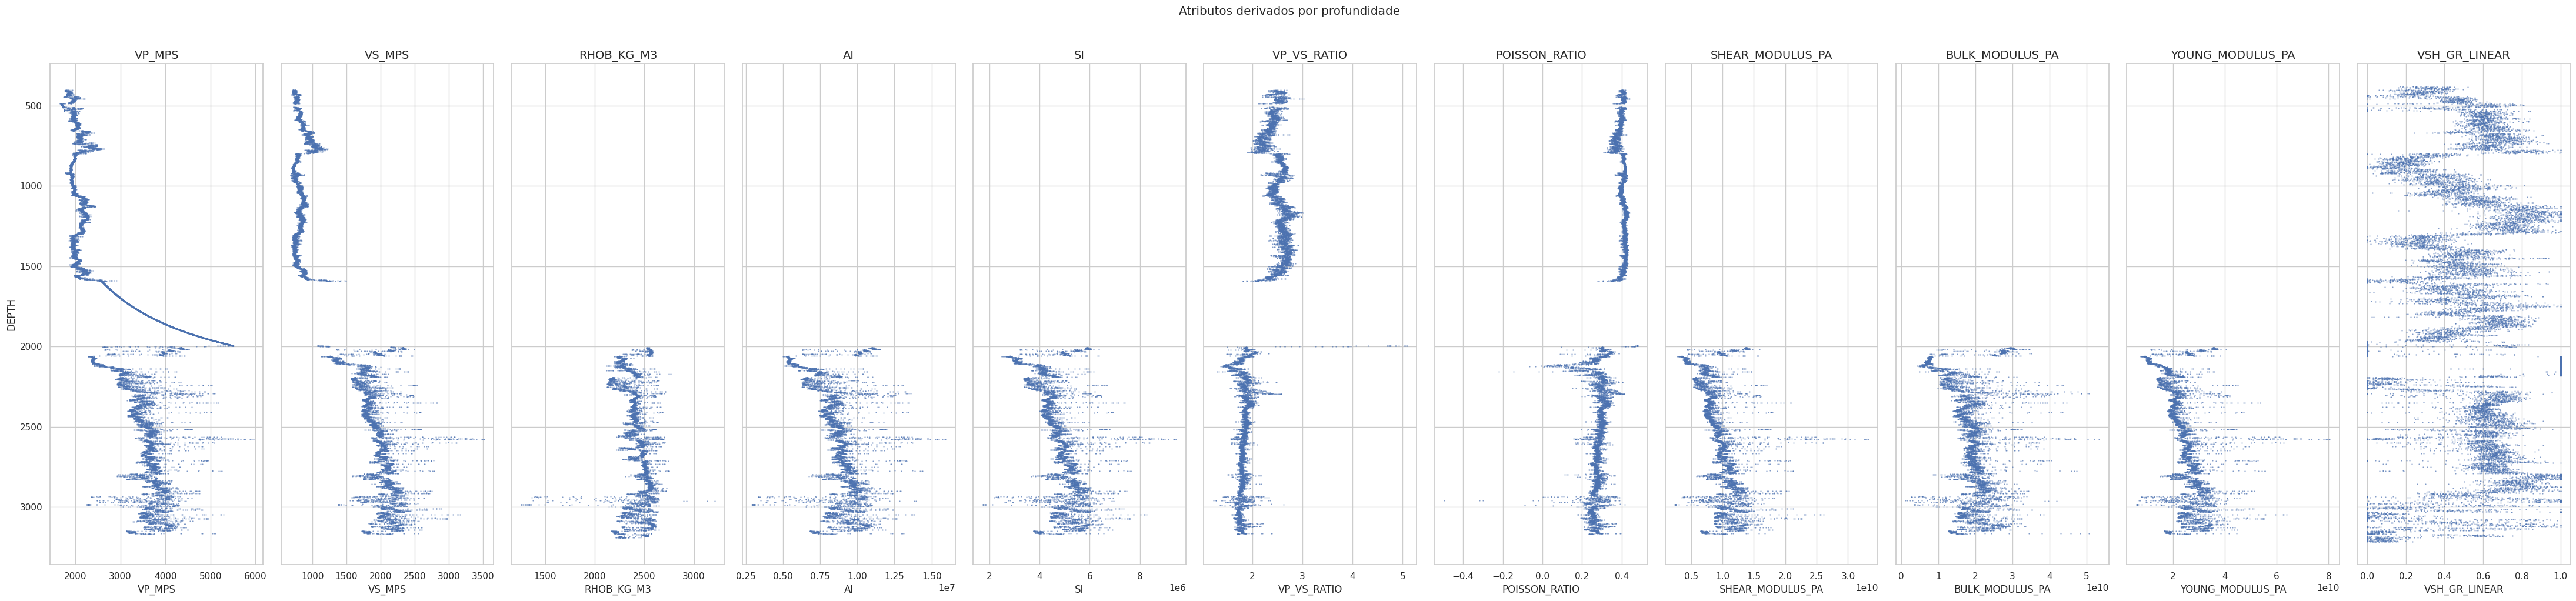

In [6]:
# ============================================================
# STEP 5 — FEATURE VISUALIZATION
# ============================================================

def plot_log_curves(df: pd.DataFrame, depth_col: str, curves: List[str], title: str, max_points: int = 30_000) -> None:
    existing_curves = [c for c in curves if c in df.columns]
    if not existing_curves:
        print("Nenhuma curva disponível para plot.")
        return
    plot_df = df[[depth_col] + existing_curves].dropna(subset=[depth_col]).copy()
    if len(plot_df) > max_points:
        step = max(1, len(plot_df) // max_points)
        plot_df = plot_df.iloc[::step].copy()
    n = len(existing_curves)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 10), sharey=True)
    if n == 1:
        axes = [axes]
    for ax, curve in zip(axes, existing_curves):
        ax.plot(plot_df[curve], plot_df[depth_col], ".", markersize=1.5, alpha=0.5)
        ax.set_title(curve)
        ax.set_xlabel(curve)
        ax.grid(True)
    axes[0].invert_yaxis()
    axes[0].set_ylabel(depth_col)
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

plot_log_curves(features_df, "DEPTH", feature_cols, "Atributos derivados por profundidade")

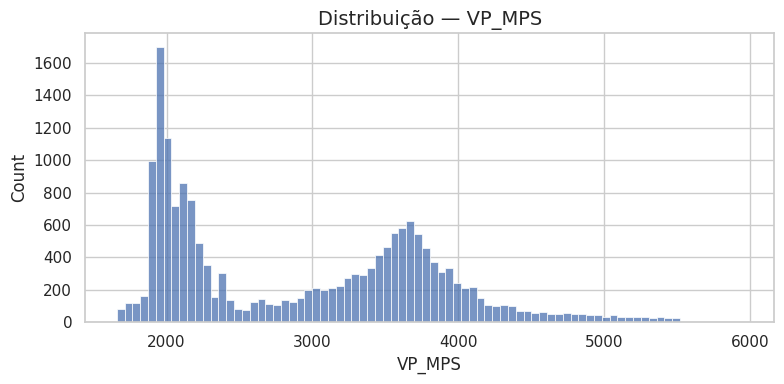

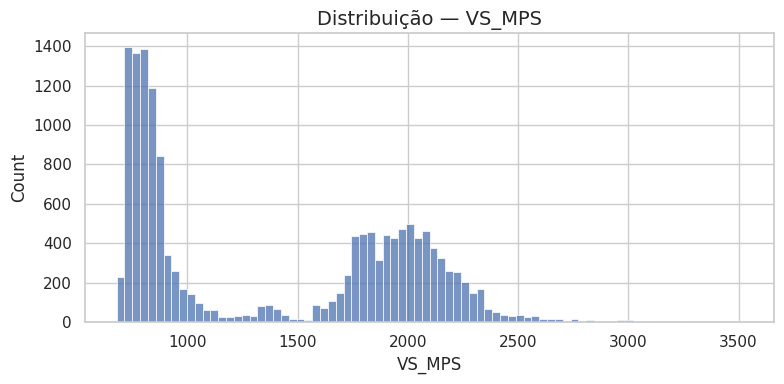

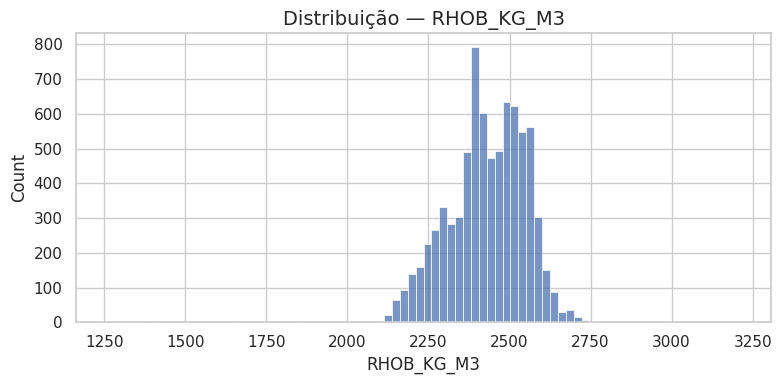

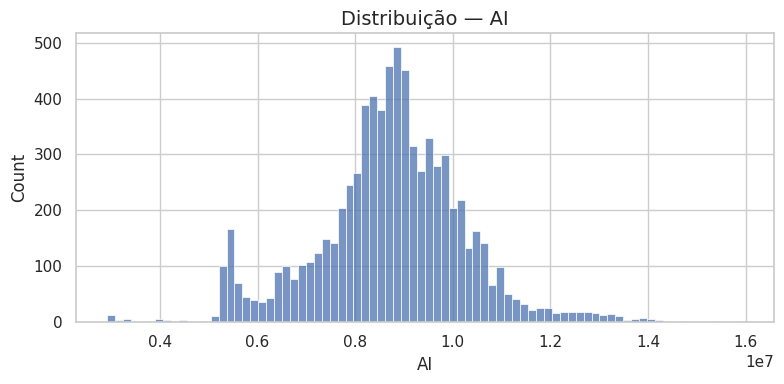

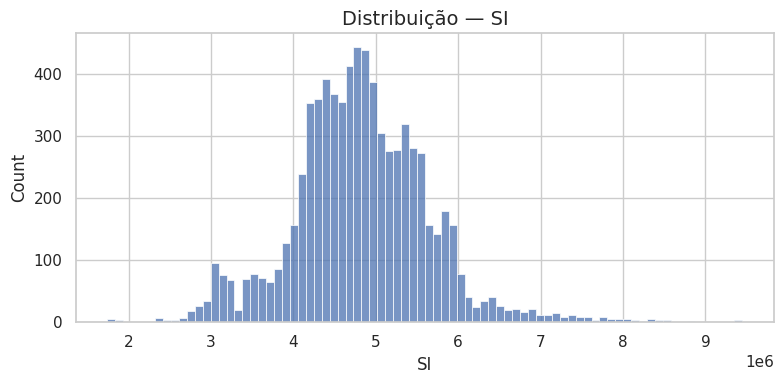

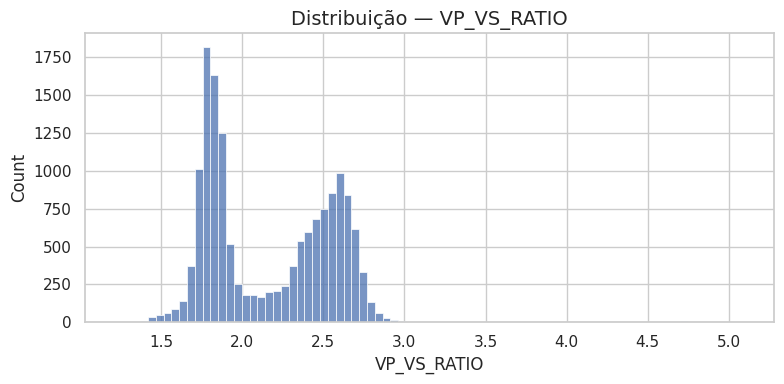

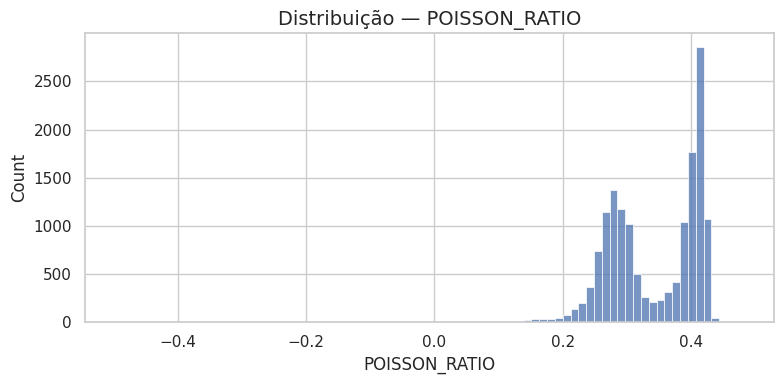

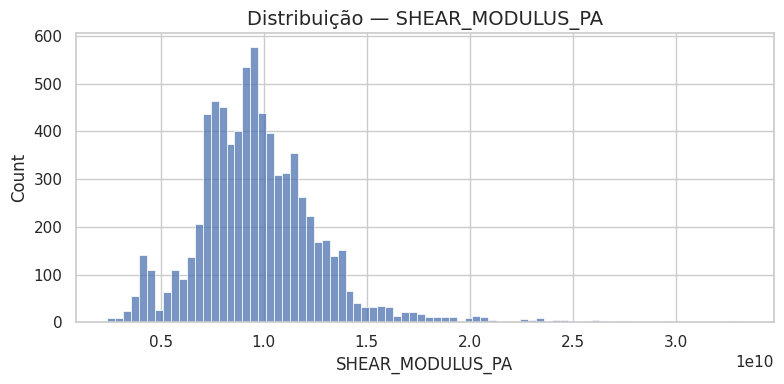

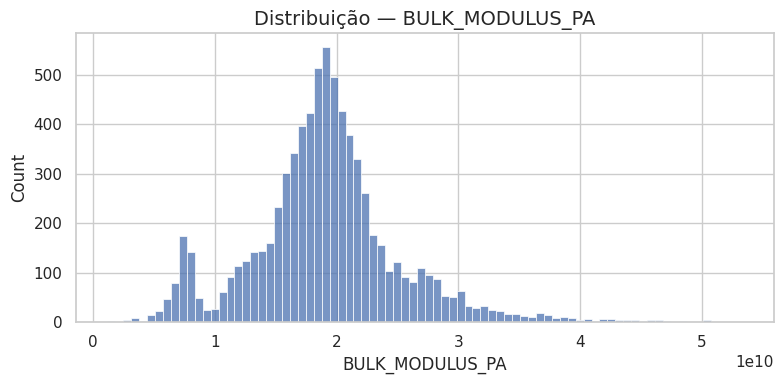

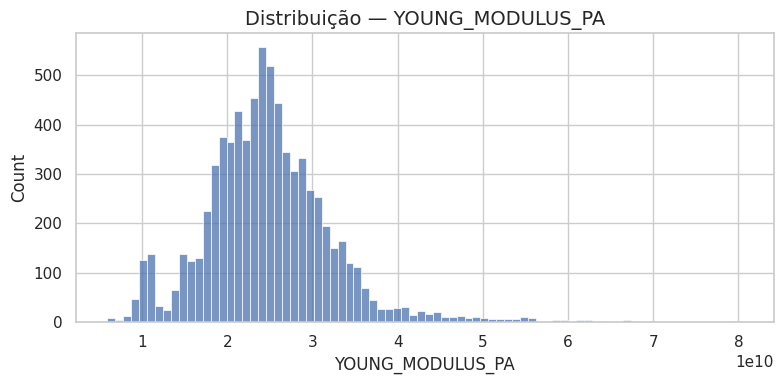

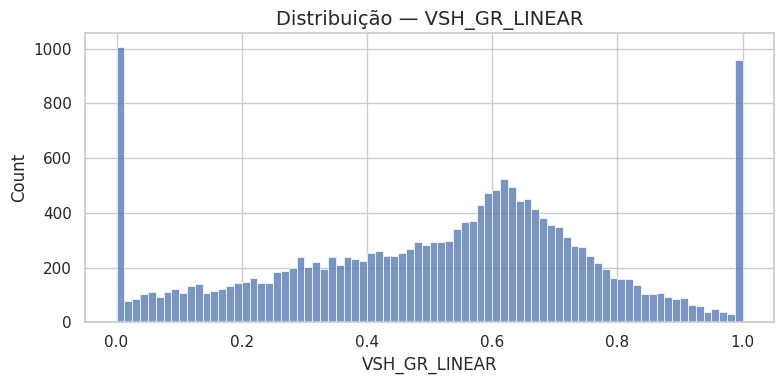

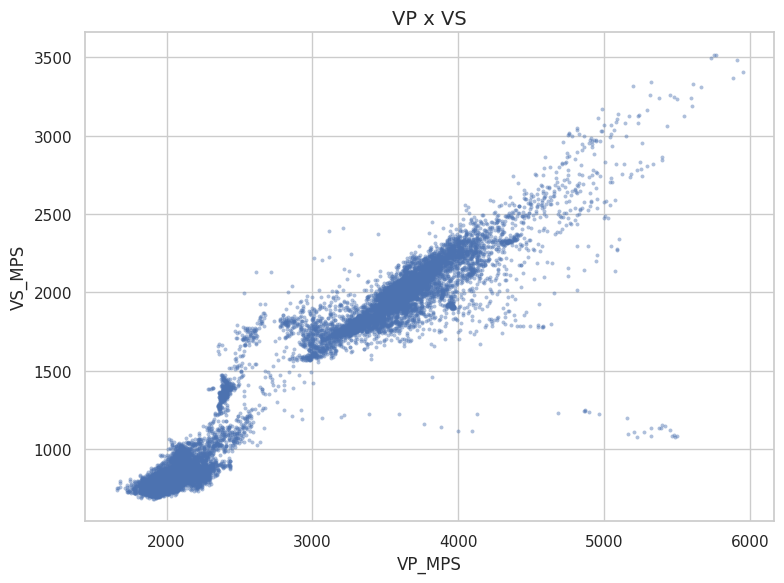

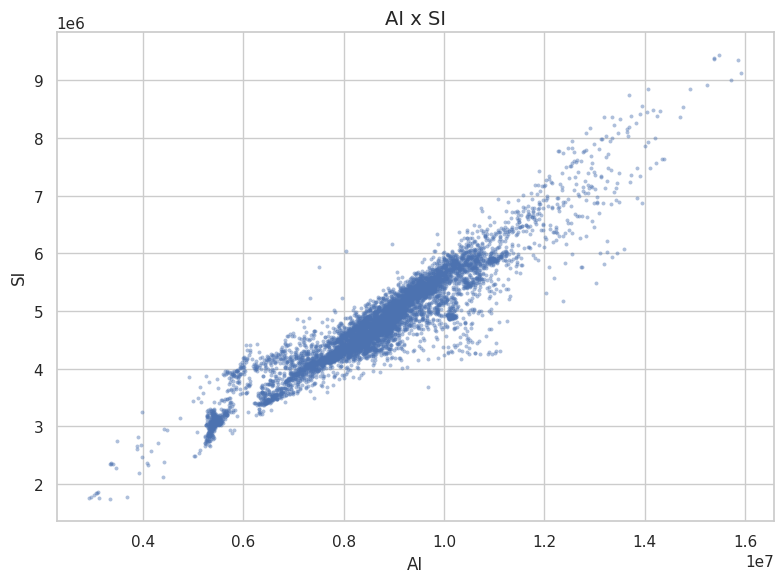

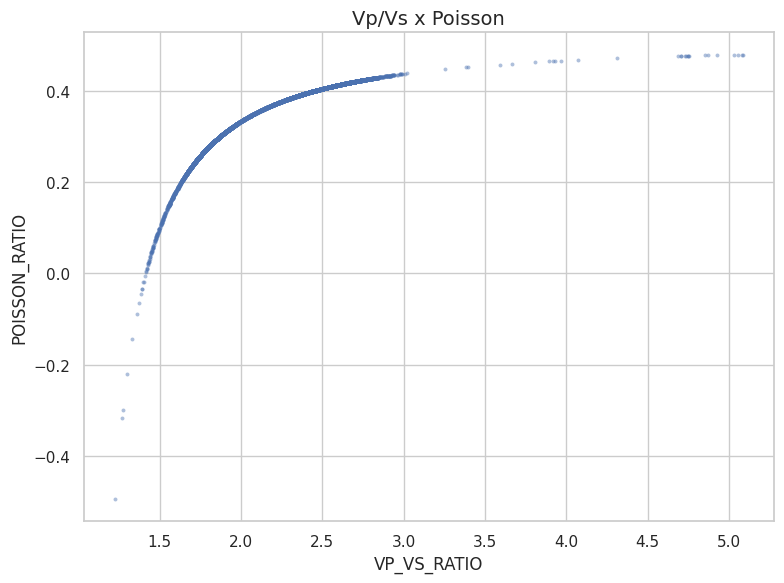

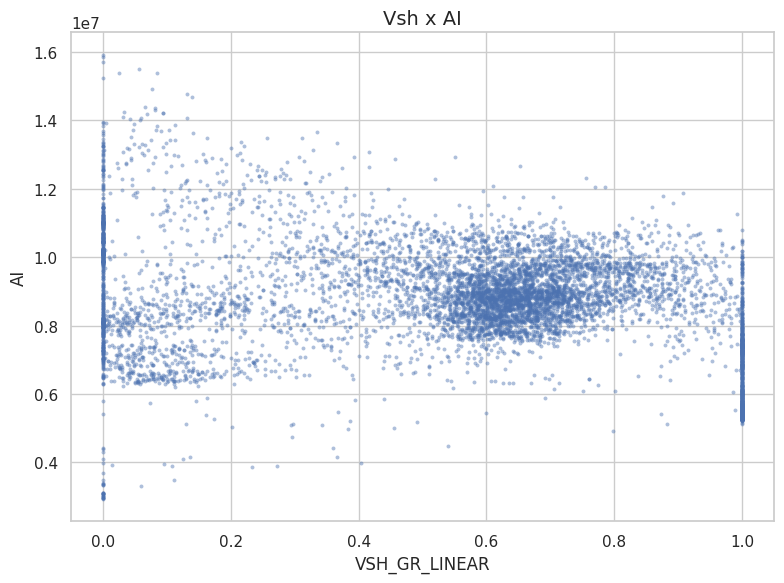

In [7]:
# ============================================================
# STEP 5.1 — HISTOGRAMAS E CROSSPLOTS RÁPIDOS
# ============================================================

for col in feature_cols:
    if col in features_df.columns and features_df[col].notna().any():
        plt.figure(figsize=(8, 4))
        sns.histplot(features_df[col].dropna(), bins=80)
        plt.title(f"Distribuição — {col}")
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()


def crossplot(df: pd.DataFrame, x: str, y: str, title: Optional[str] = None) -> None:
    if x not in df.columns or y not in df.columns:
        return
    plot_df = df[[x, y]].dropna().copy()
    if plot_df.empty:
        return
    if len(plot_df) > 50_000:
        plot_df = plot_df.sample(50_000, random_state=42)
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=plot_df, x=x, y=y, s=8, alpha=0.45, linewidth=0)
    plt.title(title or f"{x} x {y}")
    plt.tight_layout()
    plt.show()

crossplot(features_df, "VP_MPS", "VS_MPS", "VP x VS")
crossplot(features_df, "AI", "SI", "AI x SI")
crossplot(features_df, "VP_VS_RATIO", "POISSON_RATIO", "Vp/Vs x Poisson")
crossplot(features_df, "VSH_GR_LINEAR", "AI", "Vsh x AI")

# STEP 6 — Export Enriched Parquet

Salvamos a camada enriched:

```text
data/enriched/parquet/single_well_features/
```

In [8]:
# ============================================================
# STEP 6 — EXPORT ENRICHED PARQUET
# ============================================================

if "WELL" in features_df.columns and features_df["WELL"].notna().any():
    well_name = str(features_df["WELL"].dropna().iloc[0])
else:
    well_name = selected_curated_path.stem.replace("_single_well_qc_curated", "")

safe_well_name = well_name.replace("/", "_").replace(" ", "_")

preferred_order = [
    "WELL", "DEPTH",
    "GR", "RHOB", "DTC", "DTS", "NPOR",
    "RDEP", "RMED", "RSHA", "CALI", "BS", "DCALC",
    "VP_MPS", "VS_MPS", "RHOB_KG_M3",
    "AI", "SI", "VP_VS_RATIO", "POISSON_RATIO",
    "SHEAR_MODULUS_PA", "BULK_MODULUS_PA", "YOUNG_MODULUS_PA",
    "VSH_GR_LINEAR",
    "QC_FLAG_COUNT", "QC_HAS_ANY_FLAG",
    "FEATURE_QC_FLAG_COUNT", "FEATURE_QC_HAS_ANY_FLAG",
]

existing_preferred = [c for c in preferred_order if c in features_df.columns]
remaining_cols = [c for c in features_df.columns if c not in existing_preferred]
enriched_df = features_df[existing_preferred + remaining_cols].copy()

if "WELL" in enriched_df.columns:
    enriched_df["WELL"] = enriched_df["WELL"].astype("string")

bool_cols = [c for c in enriched_df.columns if c.startswith("FLAG_") or enriched_df[c].dtype == bool]
for col in bool_cols:
    enriched_df[col] = enriched_df[col].fillna(False).astype(bool)

enriched_path = DATA_ENRICHED_DIR / f"{safe_well_name}_single_well_features_enriched.parquet"
enriched_df.to_parquet(enriched_path, index=False)

column_dictionary_df = pd.DataFrame({
    "COLUMN": enriched_df.columns,
    "DTYPE": [str(enriched_df[c].dtype) for c in enriched_df.columns],
    "NON_NULL_COUNT": [enriched_df[c].notna().sum() for c in enriched_df.columns],
    "NULL_COUNT": [enriched_df[c].isna().sum() for c in enriched_df.columns],
    "FILL_RATE": [enriched_df[c].notna().mean() for c in enriched_df.columns],
})
column_dictionary_path = REPORT_DIR / f"{safe_well_name}_enriched_column_dictionary.csv"
column_dictionary_df.to_csv(column_dictionary_path, index=False)

summary_df = pd.DataFrame([{
    "WELL": well_name,
    "SOURCE_CURATED_PARQUET": str(selected_curated_path),
    "ENRICHED_ROWS": len(enriched_df),
    "ENRICHED_COLUMNS": enriched_df.shape[1],
    "DEPTH_MIN": enriched_df["DEPTH"].min(),
    "DEPTH_MAX": enriched_df["DEPTH"].max(),
    "HAS_VP_MPS": enriched_df["VP_MPS"].notna().any(),
    "HAS_VS_MPS": enriched_df["VS_MPS"].notna().any(),
    "HAS_AI": enriched_df["AI"].notna().any(),
    "HAS_POISSON_RATIO": enriched_df["POISSON_RATIO"].notna().any(),
    "GR_CLEAN_P05": gr_clean,
    "GR_SHALE_P95": gr_shale,
    "ENRICHED_PARQUET": str(enriched_path),
}])
summary_path = REPORT_DIR / f"{safe_well_name}_enriched_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("ENRICHED PARQUET EXPORTADO COM SUCESSO!")
print(f"Arquivo: {enriched_path}")
print(f"Dicionário: {column_dictionary_path}")
print(f"Resumo: {summary_path}")
display(summary_df)
display(column_dictionary_df)

ENRICHED PARQUET EXPORTADO COM SUCESSO!
Arquivo: ../data/enriched/parquet/single_well_features/TFT-4_single_well_features_enriched.parquet
Dicionário: ../reports/single_well_features/TFT-4_enriched_column_dictionary.csv
Resumo: ../reports/single_well_features/TFT-4_enriched_summary.csv


,WELL,SOURCE_CURATED_PARQUET,ENRICHED_ROWS,ENRICHED_COLUMNS,DEPTH_MIN,DEPTH_MAX,HAS_VP_MPS,HAS_VS_MPS,HAS_AI,HAS_POISSON_RATIO,GR_CLEAN_P05,GR_SHALE_P95,ENRICHED_PARQUET
0,TFT-4,../data/curated/parquet/single_well_qc/TFT-4_s...,18731,111,372.008400,"3,218.968400",True,True,True,True,45.700624,125.441013,../data/enriched/parquet/single_well_features/...


,COLUMN,DTYPE,NON_NULL_COUNT,NULL_COUNT,FILL_RATE
0,WELL,string,18731,0,1.000000
1,DEPTH,float64,18731,0,1.000000
2,GR,float64,18666,65,0.996530
3,RHOB,float64,7800,10931,0.416422
4,DTC,float64,18199,532,0.971598
5,DTS,float64,15252,3479,0.814265
6,NPOR,float64,7835,10896,0.418291
7,RDEP,float64,18567,164,0.991244
8,RMED,float64,18524,207,0.988949
9,CALI,float64,7842,10889,0.418664


# Fim do Notebook 02

Resultado produzido:

```text
data/enriched/parquet/single_well_features/
```

Próximo notebook futuro:

```text
03_single_well_analytics.ipynb
```